# EAUI 2026 — Procesamiento de datos

Carga, recodifica y prepara la Encuesta de Acceso y Uso de Internet SUBTEL 2026.

**Orden de ejecución:** Carga → GSE → Etiquetas → NS/NR → Renombrado → Recodificaciones → Funciones

## 1. Carga del archivo

In [125]:
import pyreadstat
import re
import unicodedata
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import prince
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

df, meta = pyreadstat.read_sav("/Users/tomas/GitHub/eaui_subtel/data/sav/2026.sav")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

Filas: 5,000 | Columnas: 587


## 2. GSE derivado

Se calcula aquí con los nombres originales SPSS (`A10`, `A11`), antes de cualquier renombrado o recodificación.

In [126]:
def _educ_g(e):
    if pd.isna(e): return None
    e = int(e)
    if e <= 3:  return 'basica'
    if e <= 7:  return 'media'
    if e <= 9:  return 'tecnica'
    return 'universitaria'

_M = {
    (1,'basica'):'E',  (1,'media'):'E',  (1,'tecnica'):'D',  (1,'universitaria'):'D',
    (2,'basica'):'E',  (2,'media'):'D',  (2,'tecnica'):'D',  (2,'universitaria'):'C3',
    (3,'basica'):'D',  (3,'media'):'C3', (3,'tecnica'):'C3', (3,'universitaria'):'C2',
    (4,'basica'):'C3', (4,'media'):'C2', (4,'tecnica'):'C2', (4,'universitaria'):'C1',
    (5,'basica'):'C2', (5,'media'):'C1', (5,'tecnica'):'C1', (5,'universitaria'):'AB',
    (6,'basica'):'C1', (6,'media'):'AB', (6,'tecnica'):'AB', (6,'universitaria'):'AB',
}
_ORDEN_GSE = ['AB','C1','C2','C3','D','E']  # Invertido

_eg = df['A10'].apply(_educ_g)
df['gse'] = pd.Categorical(
    df['A11'].combine(_eg, lambda o, e: np.nan if pd.isna(o) or e is None else _M.get((int(o), e), np.nan)),
    categories=_ORDEN_GSE, ordered=True  # Aquí usa el orden invertido automáticamente
)
print('GSE:', df['gse'].value_counts().reindex(_ORDEN_GSE).to_dict())

GSE: {'AB': 342, 'C1': 533, 'C2': 988, 'C3': 1316, 'D': 833, 'E': 988}


## 3. Etiquetas limpias

Construye un diccionario `etiquetas_limpias` con la etiqueta útil de cada variable SPSS.
Usado en `analizar_rm()` y consultas.

In [127]:
def limpiar_etiqueta(label):
    """Extrae la parte descriptiva útil de una etiqueta SPSS."""
    if not label: return label
    label = label.strip()
    # Patrón B/C: empieza con código de variable (P3_1 .-, Q1.3.-)
    if re.match(r'^[A-Z]\w+[\._]\w+\s*\.-?', label):
        if ':' in label:
            r = label.split(':')[-1].strip()
            if r: return r
        if '?' in label:
            r = label.split('?')[-1].strip().lstrip(':').strip()
            if r: return r
        r = re.sub(r'^[A-Z]\w+[\._]\w+[\s\._\-]+', '', label).strip()
        return r.lstrip('.-').strip()
    # Patrón A: etiqueta + [pregunta padre] (corchete abre, cierre o no)
    if '[' in label:
        r = label[:label.index('[')].strip()
        return re.sub(r'^\d+[\.-]+\s*', '', r).strip()
    # Patrón D: numeración inicial
    return re.sub(r'^\d+[\.-]+\s*', '', label).strip()


etiquetas_limpias = {
    col: limpiar_etiqueta(label)
    for col, label in zip(meta.column_names, meta.column_labels) if label
}
print(f"Etiquetas procesadas: {len(etiquetas_limpias)}")

Etiquetas procesadas: 587


## 4. Diccionario de variables originales

In [128]:
diccionario = pd.DataFrame({'variable': meta.column_names, 'etiqueta': meta.column_labels})
diccionario.head(20)

,variable,etiqueta
0,REGISTRO,Número de registro
1,FECHAFIN,Fecha de fin de la entrevista
2,COD_REGION,Región
3,COMUNA_DEF,Comuna
4,ZONA,ZONA
5,A9,A9.- ¿Cuál es su parentesco con el Jefe /a de ...
6,A10,"A10.- Pensando en el jefe de hogar, ¿cuál fue ..."
7,A11,A11.- Y ¿Cuál es la profesión o trabajo o acti...
8,A12_11,Aymara [A12.- ¿Algún miembro de este hogar per...
9,A12_2,Rapa-Nui [A12.- ¿Algún miembro de este hogar p...


In [129]:
# Buscar variable por nombre o fragmento de etiqueta
busqueda = 'A10'
diccionario[
    diccionario['variable'].str.contains(busqueda, case=False) |
    diccionario['etiqueta'].str.contains(busqueda, case=False, na=False)
]

,variable,etiqueta
6,A10,"A10.- Pensando en el jefe de hogar, ¿cuál fue ..."


In [130]:
# Ver categorías codificadas de una variable
variable = 'Q8_1'
labels = meta.variable_value_labels.get(variable, {})
if labels:
    for k, v in labels.items(): print(f'  {k} -> {v}')
else:
    print(f"'{variable}' no tiene etiquetas de valor.")

'Q8_1' no tiene etiquetas de valor.


## 5. Tratamiento NS/NR

Variables de montos usan `9999999` como código NS/NR.

In [131]:
cols_nsnr = [
    'P11','Q7_4',
    'P17_1','P17_2','P17_3','P17_4','P17_5',
    'P19_1','P19_2','P19_3','P19_4',
    'Q40_1','Q40_2','Q40_3','Q40_4','Q40_5',
    'Q42','Q42_1'
]
for col in cols_nsnr:
    if col in df.columns: df[col] = df[col].replace(9999999, np.nan)
print('NS/NR reemplazados por NaN.')

NS/NR reemplazados por NaN.


## 6. Renombrado de variables

Asigna nombres cortos a las variables principales. `educ_jh` y `ocupacion_jh` se recodifican
aquí, antes de la sección 7, porque el GSE ya fue calculado con sus valores numéricos.

In [132]:
nombres_cortos = {
    'REGISTRO':'id', 'FECHAFIN':'fecha_fin', 'COD_REGION':'region', 'COMUNA_DEF':'comuna', 'ZONA':'zona',
    'A9':'parentesco_jh', 'A10':'educ_jh', 'A11':'ocupacion_jh', 'A12_1':'ingreso_hogar',
    'Q1':'parentesco', 'Q1_1':'edad', 'Q1_2':'sexo', 'Q1_3':'educ', 'Q1_4':'ocupacion_encuestado', 'Q2':'actividad',
    'P1':'acceso_internet_hogar', 'P2':'n_smartphones_hogar', 'P2_1':'n_computadores_hogar',
    'P10':'tipo_acceso_fijo', 'P11':'pago_mensual_internet', 'P11_3':'velocidad_contratada',
    'P11_4':'calidad_acceso', 'P11_5':'cuota_mensual_gb', 'P12_2':'tipo_plan', 'P12_1':'plan_movil_tipo',
    'P14':'razon_no_acceso_principal', 'P15':'disposicion_contratar_fijo',
    'Q5':'uso_computador', 'Q7':'uso_smartphone', 'Q7_1':'smartphone_propio',
    'Q7_3':'plan_movil_tipo_ind', 'Q7_4':'pago_mensual_movil',
    'Q9':'ultimo_uso_internet', 'Q10':'frecuencia_internet', 'Q11':'tiempo_diario_internet',
    'Q13':'tipo_acceso_mas_usado', 'Q14':'uso_internet_hogar', 'Q15':'frecuencia_internet_hogar',
    'Q16':'tiempo_diario_hogar', 'Q17':'uso_internet_fuera_hogar', 'Q18':'frecuencia_fuera_hogar',
    'Q19':'tiempo_diario_fuera_hogar',
    'Q23':'internet_facilita_trabajo', 'Q25':'internet_mejora_vida', 'Q27':'ultima_compra_online',
    'Q31':'percepcion_proteccion', 'Q30_1':'reg_control_legal', 'Q30_2':'reg_control_familia', 'Q30_3':'reg_autocontrol',
    'FE_HOGAR':'fe_hogar', 'FE_PERSONAS':'fe_personas', 'POND_HOGAR':'pond_hogar', 'POND_PERSONAS':'pond_personas',
}

df = df.rename(columns={k: v for k, v in nombres_cortos.items() if k in df.columns})

# Recodificación de educ_jh y ocupacion_jh (aquí, con valores numéricos aún intactos)
_mapa_educ = {
    1:'Sin educación formal', 2:'Básica incompleta', 3:'Básica completa',
    4:'Media CH incompleta', 5:'Media TP incompleta', 6:'Media CH completa', 7:'Media TP completa',
    8:'Superior técnica incompleta', 9:'Superior técnica completa',
    10:'Superior universitaria incompleta', 11:'Superior universitaria completa'
}
_mapa_ocup = {
    1:'Trabajos ocasionales e informales', 2:'Oficio menor - obrero no calificado',
    3:'Obrero calificado - microempresario', 4:'Empleado medio - técnico - prof. independiente',
    5:'Ejecutivo medio - prof. universitario', 6:'Alto ejecutivo - empresario - directivo'
}
df['educ_jh']              = df['educ_jh'].map(_mapa_educ)
df['ocupacion_jh']         = df['ocupacion_jh'].map(_mapa_ocup)
df['ocupacion_encuestado'] = df['ocupacion_encuestado'].map({**_mapa_ocup, 7:'Sin trabajo remunerado'})

print(f"Renombradas: {len(nombres_cortos)} | Columnas totales: {df.shape[1]}")

Renombradas: 53 | Columnas totales: 588


## 7. Recodificaciones

Sobreescribe variables con valores en texto. Sin sufijos `_rec` ni `_label`.

In [133]:
df = df.copy()

# Identificación
df['region'] = df['region'].map({
    1:'Tarapacá', 2:'Antofagasta', 3:'Atacama', 4:'Coquimbo', 5:'Valparaíso',
    6:"O'Higgins", 7:'Maule', 8:'Biobío', 9:'Araucanía', 10:'Los Lagos',
    11:'Aysén', 12:'Magallanes', 13:'Metropolitana', 14:'Los Ríos', 15:'Arica y Parinacota', 16:'Ñuble'
})
df['zona'] = df['zona'].map({1:'Urbana', 2:'Rural'})

# Sociodemográficas del entrevistado
df['sexo'] = df['sexo'].map({1:'Hombre', 2:'Mujer'})
df['educ'] = df['educ'].map(_mapa_educ)
df['educ_grupo'] = df['educ'].map({
    'Sin educación formal':'Básica o menos', 'Básica incompleta':'Básica o menos',
    'Básica completa':'Básica o menos', 'Media CH incompleta':'Media',
    'Media TP incompleta':'Media', 'Media CH completa':'Media', 'Media TP completa':'Media',
    'Superior técnica incompleta':'Superior', 'Superior técnica completa':'Superior',
    'Superior universitaria incompleta':'Superior', 'Superior universitaria completa':'Superior',
})
df['tramo_edad'] = pd.cut(df['edad'], bins=[0,17,29,44,59,200],
                          labels=['Menor de 18','18-29','30-44','45-59','60 y más'], right=True)
df['actividad'] = df['actividad'].map({
    1:'Trabajador independiente', 2:'Empleador/patrón', 3:'Empleado dependiente',
    4:'Familiar no remunerado', 5:'FFAA y de orden', 6:'Cesante',
    7:'Jubilado/pensionado', 8:'Estudiante', 9:'Labores del hogar'
})

# Acceso a internet
df['acceso_internet_hogar'] = df['acceso_internet_hogar'].map({1:'Sí', 2:'No'})
df['tipo_acceso_fijo'] = df['tipo_acceso_fijo'].map({
    1:'ADSL', 2:'Cable/Módem', 3:'Fibra óptica', 4:'Inalámbrica',
    5:'Satelital', 31:'WiFi', 32:'Antena', 33:'Banda ancha', 34:'Acceso telefónico', 88:'No sabe'
})
df['velocidad_contratada'] = df['velocidad_contratada'].map({
    1:'Hasta 10 Mbps', 2:'Más de 10 a 100 Mbps', 3:'Más de 100 a 500 Mbps',
    4:'Más de 500 Mbps a 1 Gbps', 5:'Más de 1 Gbps', 99:'NS/NR'
})
df['tipo_plan'] = df['tipo_plan'].map({
    1:'Banda ancha desnuda', 2:'BA + TV Cable', 3:'BA + Telefonía fija',
    4:'Triple pack (BA+TV+Tel)', 5:'Otros planes'
})

# Uso individual
df['uso_computador']  = df['uso_computador'].map({1:'Sí', 2:'No'})
df['uso_smartphone']  = df['uso_smartphone'].map({1:'Sí', 2:'No'})
df['ultimo_uso_internet'] = df['ultimo_uso_internet'].map({
    1:'Hoy', 2:'Entre 2 y 3 días', 3:'Entre 3 y 7 días', 4:'Entre 1 y 4 semanas',
    5:'Más de 4 semanas', 6:'Más de 12 meses', 7:'Nunca'
})
df['frecuencia_internet'] = df['frecuencia_internet'].map({
    1:'Todos los días', 2:'Varias veces por semana',
    3:'Al menos una vez al mes', 4:'Menos de una vez al mes'
})
df['tiempo_diario_internet'] = df['tiempo_diario_internet'].map({
    1:'Menos de 1 hora', 2:'Entre 1 y 2 horas', 3:'Entre 2 y 4 horas', 4:'Más de 4 horas'
})

# Percepciones
df['percepcion_proteccion']     = df['percepcion_proteccion'].map({
    1:'Muy protegido', 2:'Protegido', 3:'Desprotegido', 4:'Muy desprotegido', 99:'NS/NR'
})
df['internet_mejora_vida']      = df['internet_mejora_vida'].map({1:'Sí', 2:'No'})
df['internet_facilita_trabajo'] = df['internet_facilita_trabajo'].map({1:'Sí', 2:'No'})

print('Recodificaciones completadas.')
print(f"sexo: {df['sexo'].value_counts().to_dict()}")
print(f"acceso: {df['acceso_internet_hogar'].value_counts().to_dict()}")

Recodificaciones completadas.
sexo: {'Mujer': 2815, 'Hombre': 2185}
acceso: {'Sí': 4841, 'No': 159}


## 8. Ingreso del hogar

Los rangos varían según el tamaño del hogar. Se unifica calculando el punto medio de cada rango.

In [134]:
_rangos = {
    11:(0,129000),12:(130000,226000),13:(227000,393000),14:(394000,686000),15:(687000,1100000),16:(1200000,2000000),17:(2100000,None),
    21:(0,210000),22:(211000,366000),23:(367000,639000),24:(640000,1100000),25:(1200000,1900000),26:(2000000,3300000),27:(3400000,None),
    31:(0,279000),32:(280000,487000),33:(488000,849000),34:(850000,1400000),35:(1500000,2500000),36:(2600000,4500000),37:(4600000,None),
    41:(0,341000),42:(342000,595000),43:(596000,1000000),44:(1100000,1800000),45:(1900000,3100000),46:(3200000,5500000),47:(5600000,None),
    51:(0,399000),52:(400000,696000),53:(697000,1200000),54:(1300000,2100000),55:(2200000,3600000),56:(3700000,6400000),57:(6500000,None),
    61:(0,453000),62:(454000,791000),63:(792000,1300000),64:(1400000,2400000),65:(2500000,4100000),66:(4200000,7300000),67:(7400000,None),
    71:(0,505000),72:(506000,881000),73:(882000,1500000),74:(1600000,2600000),75:(2700000,4600000),76:(4700000,8100000),77:(8200000,None),
    81:(0,555000),82:(556000,967000),83:(968000,1600000),84:(1700000,2900000),85:(3000000,5100000),86:(5200000,8900000),87:(9000000,None),
    91:(0,602000),92:(603000,1000000),93:(1100000,1800000),94:(1900000,3100000),95:(3200000,5500000),96:(5600000,9700000),97:(9800000,None),
    101:(0,648000),102:(649000,1100000),103:(1200000,1900000),104:(2000000,3400000),105:(3500000,5900000),106:(6000000,10400000),107:(10500000,None),
}
_mapa_pm = {float(k): (v[0]*1.5 if v[1] is None else (v[0]+v[1])/2) for k, v in _rangos.items()}

df['ingreso_pm'] = df['ingreso_hogar'].map(_mapa_pm)
df['ingreso_tramo'] = pd.cut(
    df['ingreso_pm'],
    bins=[0, 384000, 540000, 798000, 1100000, 1700000, float('inf')],
    labels=['Hasta $384 mil','$384 mil a $540 mil','$540 mil a $798 mil',
            '$798 mil a $1,1 millón','$1,1 millón a $1,7 millones','Más de $1,7 millones'],
    right=True
)
df['ingreso_grupo'] = df['ingreso_tramo'].map({
    'Hasta $384 mil':'Bajo', '$384 mil a $540 mil':'Bajo',
    '$540 mil a $798 mil':'Medio', '$798 mil a $1,1 millón':'Medio',
    '$1,1 millón a $1,7 millones':'Alto', 'Más de $1,7 millones':'Alto',
})

# Validación: promedio de ingreso debe subir de E a AB
(
    df.groupby('gse', observed=True)['ingreso_pm']
    .agg(N='count', Promedio='mean').reindex(_ORDEN_GSE).round(0).astype({'N':int,'Promedio':int})
)

,N,Promedio
gse,,
AB,286,2097505
C1,444,1389884
C2,826,986176
C3,1112,799533
D,704,650022
E,846,539833


## 9. Funciones de análisis ponderado

In [148]:
ORDEN_CATEGORIAS = {
    'sexo':         ['Hombre','Mujer'],
    'zona':         ['Urbana','Rural'],
    'region':       ['Tarapacá','Antofagasta','Atacama','Coquimbo','Valparaíso',"O'Higgins",'Maule',
                     'Biobío','Araucanía','Los Lagos','Aysén','Magallanes','Metropolitana',
                     'Los Ríos','Arica y Parinacota','Ñuble'],
    'educ':         ['Sin educación formal','Básica incompleta','Básica completa',
                     'Media CH incompleta','Media TP incompleta','Media CH completa','Media TP completa',
                     'Superior técnica incompleta','Superior técnica completa',
                     'Superior universitaria incompleta','Superior universitaria completa'],
    'educ_grupo':   ['Básica o menos','Media','Superior'],
    'tramo_edad':   ['Menor de 18','18-29','30-44','45-59','60 y más'],
    'actividad':    ['Trabajador independiente','Empleador/patrón','Empleado dependiente',
                     'Familiar no remunerado','FFAA y de orden','Cesante',
                     'Jubilado/pensionado','Estudiante','Labores del hogar'],
    'ocupacion_jh': ['Trabajos ocasionales e informales','Oficio menor - obrero no calificado',
                     'Obrero calificado - microempresario','Empleado medio - técnico - prof. independiente',
                     'Ejecutivo medio - prof. universitario','Alto ejecutivo - empresario - directivo'],
    'ocupacion_encuestado': ['Trabajos ocasionales e informales','Oficio menor - obrero no calificado',
                     'Obrero calificado - microempresario','Empleado medio - técnico - prof. independiente',
                     'Ejecutivo medio - prof. universitario','Alto ejecutivo - empresario - directivo',
                     'Sin trabajo remunerado'],
    'gse':              ['AB', 'C1', 'C2', 'C3', 'D', 'E'],
    'ingreso_tramo':    ['Hasta $384 mil','$384 mil a $540 mil','$540 mil a $798 mil',
                         '$798 mil a $1,1 millón','$1,1 millón a $1,7 millones','Más de $1,7 millones'],
    'ingreso_grupo':    ['Bajo','Medio','Alto'],
    'acceso_internet_hogar':    ['Sí','No'],
    'uso_computador':           ['Sí','No'],
    'uso_smartphone':           ['Sí','No'],
    'internet_mejora_vida':     ['Sí','No'],
    'internet_facilita_trabajo':['Sí','No'],
    'ultimo_uso_internet':      ['Hoy','Entre 2 y 3 días','Entre 3 y 7 días',
                                  'Entre 1 y 4 semanas','Más de 4 semanas','Más de 12 meses','Nunca'],
    'frecuencia_internet':      ['Todos los días','Varias veces por semana',
                                  'Al menos una vez al mes','Menos de una vez al mes'],
    'tiempo_diario_internet':   ['Menos de 1 hora','Entre 1 y 2 horas','Entre 2 y 4 horas','Más de 4 horas'],
    'percepcion_proteccion':    ['Muy protegido','Protegido','Desprotegido','Muy desprotegido','NS/NR'],
    'velocidad_contratada':     ['Hasta 10 Mbps','Más de 10 a 100 Mbps','Más de 100 a 500 Mbps',
                                  'Más de 500 Mbps a 1 Gbps','Más de 1 Gbps','NS/NR'],
}


def fordf(df_tabla, titulo=None):
    """Formato visual: enteros sin decimales, porcentajes con 1 decimal."""
    
    # 1. Identificar solo las columnas que son numéricas
    num_cols = df_tabla.select_dtypes(include=['number']).columns
    
    # 2. Aplicar el formato solo a esas columnas
    estilo = df_tabla.style.format({
        col: '{:,.0f}' if 'ponderado' in str(col).lower() or 'total' in str(col).lower() or str(col).startswith('n ') else '{:.1f}'
        for col in num_cols
    })
    
    if titulo: 
        estilo = estilo.set_caption(titulo)
        
    return estilo




def _ordenar(df_res, var, cruzada=False):
    if var not in ORDEN_CATEGORIAS: return df_res
    orden = ORDEN_CATEGORIAS[var]
    if cruzada:
        ok  = [v for v in orden if v in df_res.index]
        rst = [v for v in df_res.index if v not in ok and v != 'Total']
        fin = ok + rst + (['Total'] if 'Total' in df_res.index else [])
        return df_res.reindex(fin)
    ok  = [v for v in orden if v in df_res[var].values]
    rst = [v for v in df_res[var].values if v not in ok and v != 'Total']
    df_res[var] = pd.Categorical(df_res[var], categories=ok+rst+['Total'], ordered=True)
    return df_res.sort_values(var).reset_index(drop=True)


def dstats(data_df, variables, tipo='frecuencia', cruce=None, factor=None, transponer=False, estilo=True):
    """
    Análisis ponderado de variables simples.
    tipo: 'frecuencia' | 'cruzada' | 'promedio' | 'suma'
    Si estilo=True, retorna Styler formateado. Si es False, retorna el DataFrame puro.
    Ejemplo: dstats(df, 'sexo', tipo='frecuencia', factor='fe_personas', estilo=False)
    """
    if isinstance(variables, str): variables = [variables]
    for col in variables + [factor] + ([cruce] if cruce else []):
        if col not in data_df.columns:
            raise ValueError(f"Columna '{col}' no existe.")

    if tipo == 'frecuencia':
        var = variables[0]
        tot = data_df[factor].sum()
        res = data_df.groupby(var, observed=True)[factor].sum().reset_index().rename(columns={factor:'n_ponderado'})
        res['porcentaje'] = (res['n_ponderado'] / tot * 100).round(2)
        res = pd.concat([res, pd.DataFrame({var:['Total'],'n_ponderado':[res['n_ponderado'].sum()],'porcentaje':[res['porcentaje'].sum().round(2)]})], ignore_index=True)
        res = _ordenar(res, var).set_index(var)
        
        if estilo:
            titulo = f"Frecuencia: '{var}' — base ponderada: {tot:,.0f} ({factor})"
            return fordf(res, titulo=titulo)
        return res

    if tipo == 'cruzada':
        var = variables[0]
        tot = data_df[factor].sum()
        t   = data_df.pivot_table(values=factor, index=var, columns=cruce, aggfunc='sum', fill_value=0, observed=False)
        tp  = t.div(t.sum(axis=0), axis=1).mul(100).round(2)
        if var in ORDEN_CATEGORIAS:
            of = [v for v in ORDEN_CATEGORIAS[var] if v in t.index];  t, tp = t.reindex(of), tp.reindex(of)
        if cruce in ORDEN_CATEGORIAS:
            oc = [v for v in ORDEN_CATEGORIAS[cruce] if v in t.columns]; t, tp = t[oc], tp[oc]
        if transponer: t, tp = t.T, tp.T
        t.loc['Total'], tp.loc['Total'] = t.sum(numeric_only=True), tp.sum(numeric_only=True).round(2)
        cols = [s for c in t.columns for s in [t[c].rename(f'n {c}'), tp[c].rename(f'% {c}')]]
        res = pd.concat(cols, axis=1)
        
        if estilo:
            titulo = f"Cruce: '{var}' según '{cruce}' — base ponderada: {tot:,.0f} ({factor})"
            return fordf(res, titulo=titulo)
        return res

    def _wavg(sub, v, f):
        d = sub[[v, f]].dropna()
        return float(round(np.average(d[v], weights=d[f]), 4)) if len(d) > 0 and d[f].sum() > 0 else np.nan

    def _wsum(sub, v, f):
        d = sub[[v, f]].dropna()
        return float(round((d[v]*d[f]).sum(), 4))

    fn = _wavg if tipo == 'promedio' else _wsum
    col_name = 'promedio_ponderado' if tipo == 'promedio' else 'suma_ponderada'

    if not cruce:
        res = pd.DataFrame([(v, fn(data_df, v, factor)) for v in variables], columns=['variable', col_name])
        
        if estilo:
            titulo = f"{tipo.capitalize()} de variables — factor: {factor}"
            return fordf(res, titulo=titulo)
        return res

    filas = {g: {v: fn(sg, v, factor) for v in variables} for g, sg in data_df.groupby(cruce, observed=True)}
    filas['Total'] = {v: fn(data_df, v, factor) for v in variables}
    res = pd.DataFrame(filas).T
    res.index.name = cruce
    if cruce in ORDEN_CATEGORIAS:
        ok  = [v for v in ORDEN_CATEGORIAS[cruce] if v in res.index]
        rst = [v for v in res.index if v not in ok and v != 'Total']
        res = res.reindex(ok + rst + ['Total'])
        
    if estilo:
        titulo = f"{tipo.capitalize()} cruzado por '{cruce}' — factor: {factor}"
        return fordf(res, titulo=titulo)
    return res


print('ORDEN_CATEGORIAS, fordf, dstats listos.')

ORDEN_CATEGORIAS, fordf, dstats listos.


## 10. Grupos de respuesta múltiple

In [136]:
_c = df.columns

GRUPOS_RM = {
    # Hogar
    'A12':  ('Pueblos indígenas o tribales (hogar)',            [c for c in _c if c.startswith('A12_') and not c.startswith('A12_1')]),
    'A13':  ('Condiciones permanentes de salud en el hogar',   [c for c in _c if c.startswith('A13_')]),
    'A14':  ('Situaciones laborales en el hogar',              [c for c in _c if c.startswith('A14_') and not c.endswith('_OTRA')]),
    # Acceso y conectividad
    'P3':   ('Dispositivos usados para acceder a internet',    [c for c in _c if c.startswith('P3_') and not c.endswith('_OTRA')]),
    'P4':   ('Formas de acceso pagado a internet en el hogar', [c for c in _c if c.startswith('P4_')]),
    'P6':   ('Razones para tener internet fijo',               [c for c in _c if c.startswith('P6_') and not c.startswith('P6_1_') and not c.endswith('_OTRA')]),
    'P6_1': ('Razones para tener internet móvil',              [c for c in _c if c.startswith('P6_1_')]),
    'P7':   ('Medidas de protección internet para menores',    [c for c in _c if c.startswith('P7_')]),
    'P9':   ('Dispositivos de uso personal de menores',        [c for c in _c if c.startswith('P9_')]),
    'P12':  ('Conexión móvil 4G/5G',                           ['P12_11','P12_21','P12_31','P12_41']),
    'P13':  ('Razones de no acceso a internet fijo',           [c for c in _c if c.startswith('P13_') and not c.endswith('_OTRA')]),
    'P16':  ('Equipos que le interesaría tener (sin internet)',[c for c in _c if c.startswith('P16_')]),
    # Uso individual
    'Q6':   ('¿Cómo aprendió a usar el computador?',           [c for c in _c if c.startswith('Q6_') and c not in ['Q6_1','Q6_OTRA']]),
    'Q7_2': ('Smartphone 4G/5G',                               ['Q7_2_1','Q7_2_2','Q7_2_3','Q7_2_4']),
    'Q8':   ('Habilidades digitales',                          [c for c in _c if c.startswith('Q8_')]),
    'Q11_1':('Lugares donde usó internet ayer',                [c for c in _c if c.startswith('Q11_1_')]),
    'Q12':  ('Tipos de acceso en últimos 3 meses',             [c for c in _c if c.startswith('Q12_')]),
    'Q20':  ('Lugares donde usó internet fuera del hogar',     [c for c in _c if c.startswith('Q20_')]),
    'Q21':  ('Actividades realizadas en internet',             [c for c in _c if c.startswith('Q21_') and c not in ['Q21_1','Q21_10','Q21_19','Q21_26','Q21_33','Q21_38','Q21_44']]),
    'Q28':  ('Bienes y servicios comprados en internet',       [c for c in _c if c.startswith('Q28_') and not c.endswith('_OTRA')]),
    'Q32':  ('Actividades de seguridad y privacidad',          [c for c in _c if c.startswith('Q32_') and not c.endswith('_OTRA')]),
    'Q33':  ('Problemas de seguridad sufridos',                [c for c in _c if c.startswith('Q33_') and not c.endswith('_OTRA')]),
    'Q34':  ('Razones de no uso de internet',                  [c for c in _c if c.startswith('Q34_') and not c.endswith('_OTRA')]),
    'Q37':  ('Actividades de internet realizadas por terceros',[c for c in _c if c.startswith('Q37_')]),
    'Q39':  ('Equipos que le interesaría tener (no usuarios)', [c for c in _c if c.startswith('Q39_')]),
}

def analizar_rm(grupo, factor='fe_hogar', top_n=None, estilo=True):
    """
    Analiza un grupo de respuesta múltiple.
    Si estilo=True, retorna tabla estilizada (HTML). Si es False, retorna el DataFrame puro.
    """
    if grupo not in GRUPOS_RM: 
        raise ValueError(f"Grupo '{grupo}' no existe.")
        
    desc, cols = GRUPOS_RM[grupo]
    cols = [c for c in cols if c in df.columns]
    base = df.loc[df[cols].notna().any(axis=1), factor].sum()
    
    filas = [
        {'variable': c,
         'etiqueta': etiquetas_limpias.get(c, c),
         'n_ponderado': int(df.loc[df[c]==1, factor].sum()),
         'porcentaje': round(df.loc[df[c]==1, factor].sum() / base * 100, 1)}
        for c in cols
    ]
    res = pd.DataFrame(filas).sort_values('porcentaje', ascending=False).reset_index(drop=True)
    if top_n: res = res.head(top_n)
    res.index += 1
    
    if estilo:
        titulo_tabla = f"{desc} — base ponderada: {int(base):,} ({factor})"
        return fordf(res, titulo=titulo_tabla)
    return res

print("Grupos de respuesta múltiple disponibles:")
for k, (desc, cols) in GRUPOS_RM.items():
    cols_validas = [c for c in cols if c in df.columns]
    print(f"  '{k}': {desc} ({len(cols_validas)} opciones)")

Grupos de respuesta múltiple disponibles:
  'A12': Pueblos indígenas o tribales (hogar) (8 opciones)
  'A13': Condiciones permanentes de salud en el hogar (7 opciones)
  'A14': Situaciones laborales en el hogar (8 opciones)
  'P3': Dispositivos usados para acceder a internet (8 opciones)
  'P4': Formas de acceso pagado a internet en el hogar (5 opciones)
  'P6': Razones para tener internet fijo (13 opciones)
  'P6_1': Razones para tener internet móvil (13 opciones)
  'P7': Medidas de protección internet para menores (12 opciones)
  'P9': Dispositivos de uso personal de menores (4 opciones)
  'P12': Conexión móvil 4G/5G (4 opciones)
  'P13': Razones de no acceso a internet fijo (29 opciones)
  'P16': Equipos que le interesaría tener (sin internet) (5 opciones)
  'Q6': ¿Cómo aprendió a usar el computador? (12 opciones)
  'Q7_2': Smartphone 4G/5G (4 opciones)
  'Q8': Habilidades digitales (19 opciones)
  'Q11_1': Lugares donde usó internet ayer (9 opciones)
  'Q12': Tipos de acceso en últ

In [137]:
def analizar_rm_cruce(grupo, cruce, factor='fe_personas', estilo=True):
    """
    Analiza un grupo de respuesta múltiple cruzado por una variable demográfica.
    Si estilo=True, retorna tabla estilizada (HTML). Si es False, retorna el DataFrame puro.
    """
    if grupo not in GRUPOS_RM: 
        raise ValueError(f"Grupo '{grupo}' no existe.")
        
    desc, cols = GRUPOS_RM[grupo]
    cols = [c for c in cols if c in df.columns]
    
    base_cruce = df.loc[df[cols].notna().any(axis=1)].groupby(cruce, observed=True)[factor].sum()
    
    resultados = {}
    for categoria in base_cruce.index:
        base = base_cruce[categoria]
        df_cat = df[df[cruce] == categoria]
        
        pcts = {
            etiquetas_limpias.get(c, c): round((df_cat.loc[df_cat[c]==1, factor].sum() / base) * 100, 1) 
            if base > 0 else 0 
            for c in cols
        }
        resultados[categoria] = pcts
        
    res_df = pd.DataFrame(resultados)
    res_df = res_df.sort_values(by=res_df.columns[0], ascending=False)
    
    if estilo:
        titulo_tabla = f"{desc} cruzado por '{cruce}' — factor: {factor}"
        return fordf(res_df, titulo=titulo_tabla)
    return res_df

---
# Análisis

In [138]:
dstats(df, 'sexo', tipo='frecuencia', factor='fe_personas', estilo=True)

,n_ponderado,porcentaje
sexo,,
Hombre,"6,681,550",48.4
Mujer,"7,129,211",51.6
Total,"13,810,761",100.0


In [139]:
analizar_rm('Q8', factor='fe_personas')

,variable,etiqueta,n_ponderado,porcentaje
1,Q8_12,"Revisar redes sociales (Facebook, Instagram, Whatapps, Youtube, TikTok, etc)","11,282,482",84.9
2,Q8_15,Realizar videollamdas,"11,271,083",84.8
3,Q8_16,Enviar y recibir correos con o sin archivos adjuntos,"9,780,624",73.6
4,Q8_17,"Realizar transacciones bancarias, compras y pagos en línea","9,529,520",71.7
5,Q8_14,Editar fotografías o videos,"8,213,889",61.8
6,Q8_1,Uso de procesador de texto (ej: Word),"7,898,264",59.4
7,Q8_13,Subir contenidos o realizar posteos en redes sociales,"7,666,711",57.7
8,Q8_4,"Duplicar o transferir archivos entre dispositivos (cámaras digitales, celulares, reproductores de música) o en la nube","7,115,863",53.6
9,Q8_10,"Conectarme a sitios o aplicaciones para ver videos, series y película o escuchar música","7,043,538",53.0
10,Q8_5,"Conectar un nuevo dispositivo (como un router, cámara o impresora)","7,012,591",52.8


In [140]:
analizar_rm_cruce('A12', cruce='gse', factor='fe_personas')

,AB,C1,C2,C3,D,E
Mapuche,3.9,7.5,9.5,9.2,12.2,11.8
Kawéskar,0.7,0.0,0.0,0.0,0.0,0.0
Quechua,0.4,0.1,0.1,0.1,0.3,0.2
Colla,0.1,0.1,0.1,0.1,0.0,0.1
Rapa-Nui,0.0,0.0,0.0,0.0,0.0,0.0
Atacameño,0.0,0.2,0.3,0.2,0.2,0.2
Chango,0.0,0.0,0.1,0.0,0.0,0.3
Selk’nam,0.0,0.0,0.0,0.0,0.0,0.1


## 11. Habilidades digitales Q8 — clasificación por nivel

In [141]:
# Clasificación de habilidades Q8 por nivel de dificultad
# Criterio: nivel más alto alcanzado (jerárquico)
#
# Básico     — consumo y comunicación cotidiana (6 ítems)
# Intermedio — productividad, gestión y creación (9 ítems)
# Avanzado   — configuración técnica y programación (3 ítems)

Q8_BASICO = {
    'Q8_10': 'Streaming (video/música)',
    'Q8_11': 'Juegos en línea',
    'Q8_12': 'Revisar redes sociales',
    'Q8_13': 'Publicar en redes sociales',
    'Q8_15': 'Videollamadas',
    'Q8_16': 'Correo electrónico',
}
Q8_INTERMEDIO = {
    'Q8_1':  'Procesador de texto (Word)',
    'Q8_2':  'Planilla de cálculo (Excel)',
    'Q8_3':  'Presentaciones (PowerPoint)',
    'Q8_4':  'Transferir archivos / nube',
    'Q8_5':  'Conectar nuevo dispositivo',
    'Q8_6':  'Instalar y configurar apps',
    'Q8_14': 'Editar fotos o videos',
    'Q8_17': 'Transacciones y pagos en línea',
    'Q8_18': 'Uso de IA (ChatGPT, etc.)',
}
Q8_AVANZADO = {
    'Q8_7': 'Configurar seguridad del dispositivo',
    'Q8_8': 'Instalar SO / programar (Python, Java…)',
    'Q8_9': 'Crear un sitio web',
}

_cols_b  = list(Q8_BASICO)
_cols_i  = list(Q8_INTERMEDIO)
_cols_a  = list(Q8_AVANZADO)
_cols_q8 = _cols_b + _cols_i + _cols_a + ['Q8_19']

def _nivel(row):
    if row[_cols_a].eq(1).any():  return 'Avanzado'
    if row[_cols_i].eq(1).any():  return 'Intermedio'
    if row[_cols_b].eq(1).any():  return 'Básico'
    return 'Sin habilidades'

# Crear nivel_habilidades en df (5 000 filas)
# Quienes no respondieron Q8 caen en 'Sin habilidades' (eq(1) es False para NaN)
df['nivel_habilidades'] = df.apply(_nivel, axis=1)
mask_q8 = df[_cols_q8].notna().any(axis=1)  # máscara para la tabla de ítems Q8
base_q8 = int(mask_q8.sum())

# Distribución sin ponderar (descriptiva)
orden_nivel = ['Avanzado', 'Intermedio', 'Básico', 'Sin habilidades']
dist = df['nivel_habilidades'].value_counts().reindex(orden_nivel)
print(f"Base: {len(df):,} (total df) | respondentes Q8: {base_q8:,}\n")
print("Distribución (sin ponderar):")
for niv, n in dist.items():
    pct = n / len(df) * 100
    print(f"  {niv:<20} {n:>5,}  ({pct:.1f}%)")

# Tabla de habilidades por nivel (base: respondentes Q8)
print("\n── Habilidades por nivel ──────────────────────────────────────────────")
for nivel, items in [('BÁSICO', Q8_BASICO), ('INTERMEDIO', Q8_INTERMEDIO), ('AVANZADO', Q8_AVANZADO)]:
    print(f"\n{nivel}")
    for cod, desc in items.items():
        n = int((df.loc[mask_q8, cod] == 1).sum())
        pct = n / base_q8 * 100
        print(f"  {cod:<8} {desc:<45}  {n:>5,} ({pct:.1f}%)")


Base: 5,000 (total df) | respondentes Q8: 4,758

Distribución (sin ponderar):
  Avanzado             1,548  (31.0%)
  Intermedio           2,226  (44.5%)
  Básico                 805  (16.1%)
  Sin habilidades        421  (8.4%)

── Habilidades por nivel ──────────────────────────────────────────────

BÁSICO
  Q8_10    Streaming (video/música)                       2,004 (42.1%)
  Q8_11    Juegos en línea                                1,646 (34.6%)
  Q8_12    Revisar redes sociales                         3,890 (81.8%)
  Q8_13    Publicar en redes sociales                     2,352 (49.4%)
  Q8_15    Videollamadas                                  3,886 (81.7%)
  Q8_16    Correo electrónico                             3,086 (64.9%)

INTERMEDIO
  Q8_1     Procesador de texto (Word)                     2,414 (50.7%)
  Q8_2     Planilla de cálculo (Excel)                    2,033 (42.7%)
  Q8_3     Presentaciones (PowerPoint)                    1,995 (41.9%)
  Q8_4     Transferir archivos

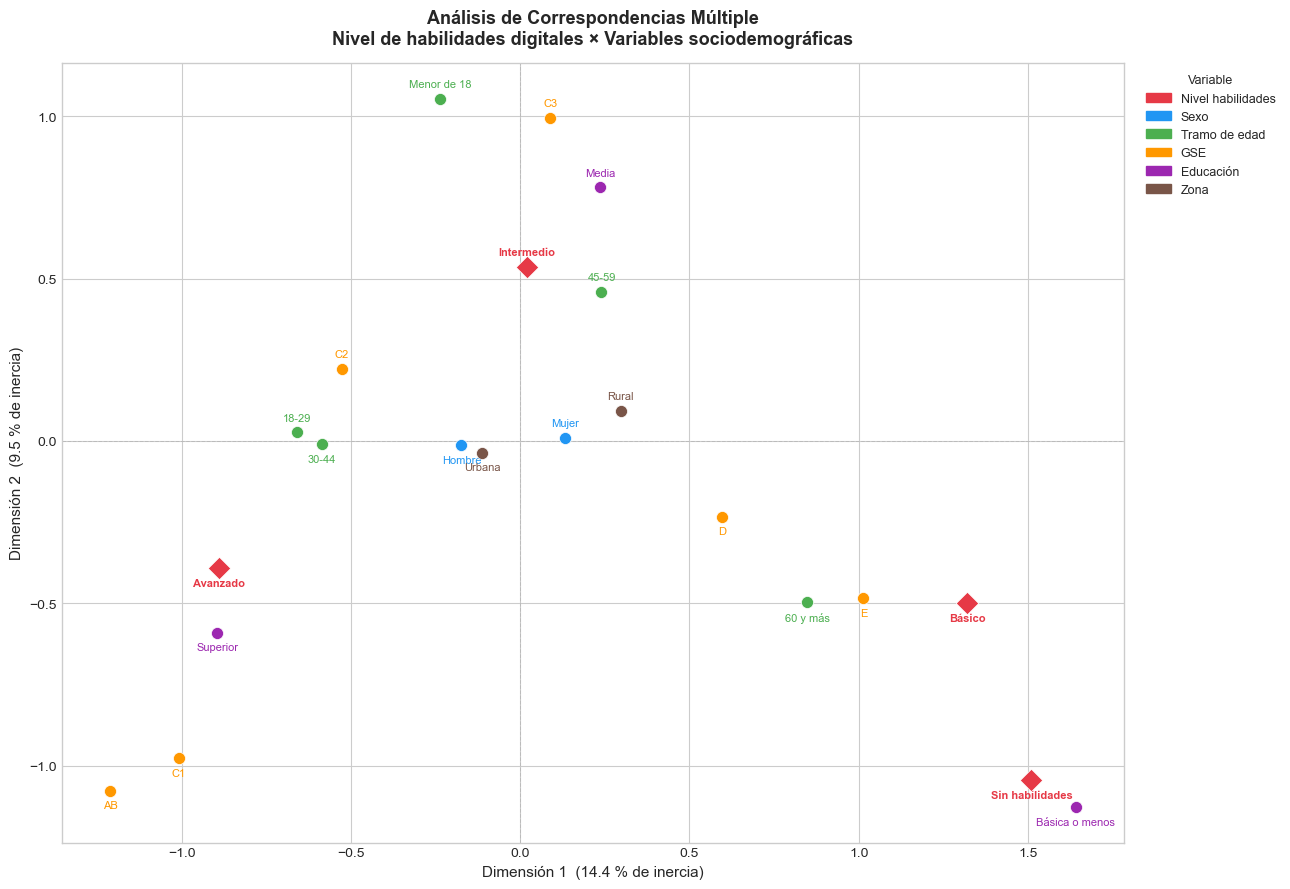


Inercia: Dim1 = 14.4%  |  Dim2 = 9.5%  |  Acumulada = 23.9%
Base ACM: 4,758 observaciones (complete cases sobre 4,758 respondentes Q8)


In [142]:
# ── Variables para el ACM ────────────────────────────────────────────────────
VAR_SOCIO = ['sexo', 'tramo_edad', 'gse', 'educ_grupo', 'zona']
VAR_ACM   = ['nivel_habilidades'] + VAR_SOCIO

df_acm = df.loc[mask_q8, VAR_ACM].dropna().copy()
for col in VAR_ACM:
    df_acm[col] = df_acm[col].astype(str)

# ── Ajuste del ACM ───────────────────────────────────────────────────────────
mca = prince.MCA(n_components=2, n_iter=10, random_state=42)
mca.fit(df_acm)

col_coords = mca.column_coordinates(df_acm)   # índice: 'variable__categoria'
dim1_pct   = mca.eigenvalues_[0] / mca.total_inertia_ * 100
dim2_pct   = mca.eigenvalues_[1] / mca.total_inertia_ * 100

# ── Parsear 'variable__categoria' ────────────────────────────────────────────
def _parse_idx(idx, vars_list):
    for v in sorted(vars_list, key=len, reverse=True):
        if idx.startswith(v + '__'):
            return v, idx[len(v) + 2:]
    return None, idx

parsed = {idx: _parse_idx(idx, VAR_ACM) for idx in col_coords.index}

# ── Paleta y etiquetas ───────────────────────────────────────────────────────
PALETA = {
    'nivel_habilidades': '#E63946',
    'sexo':              '#2196F3',
    'tramo_edad':        '#4CAF50',
    'gse':               '#FF9800',
    'educ_grupo':        '#9C27B0',
    'zona':              '#795548',
}
ETIQ_VAR = {
    'nivel_habilidades': 'Nivel habilidades',
    'sexo':              'Sexo',
    'tramo_edad':        'Tramo de edad',
    'gse':               'GSE',
    'educ_grupo':        'Educación',
    'zona':              'Zona',
}

# ── Biplot (coordenadas de categorías) ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))

for idx_val, (var, cat) in parsed.items():
    if var is None:
        continue
    x = float(col_coords.loc[idx_val, 0])
    y = float(col_coords.loc[idx_val, 1])
    color  = PALETA[var]
    marker = 'D' if var == 'nivel_habilidades' else 'o'
    size   = 130 if var == 'nivel_habilidades' else 75
    fw     = 'bold' if var == 'nivel_habilidades' else 'normal'

    ax.scatter(x, y, c=color, s=size, marker=marker, zorder=5,
               edgecolors='white', linewidths=0.5)

    va   = 'bottom' if y >= 0 else 'top'
    yoff = 7 if y >= 0 else -7
    ax.annotate(cat, (x, y), fontsize=8, ha='center', va=va,
                xytext=(0, yoff), textcoords='offset points',
                color=color, fontweight=fw)

ax.axhline(0, color='#bbb', lw=0.7, ls='--')
ax.axvline(0, color='#bbb', lw=0.7, ls='--')
ax.set_xlabel(f'Dimensión 1  ({dim1_pct:.1f} % de inercia)', fontsize=11)
ax.set_ylabel(f'Dimensión 2  ({dim2_pct:.1f} % de inercia)', fontsize=11)
ax.set_title(
    'Análisis de Correspondencias Múltiple\n'
    'Nivel de habilidades digitales × Variables sociodemográficas',
    fontsize=13, fontweight='bold', pad=14,
)

handles = [mpatches.Patch(color=PALETA[v], label=ETIQ_VAR[v]) for v in VAR_ACM]
ax.legend(handles=handles, title='Variable', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=9, title_fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

print(f"\nInercia: Dim1 = {dim1_pct:.1f}%  |  Dim2 = {dim2_pct:.1f}%  |  Acumulada = {dim1_pct + dim2_pct:.1f}%")
print(f"Base ACM: {len(df_acm):,} observaciones (complete cases sobre {base_q8:,} respondentes Q8)")

# **Generador de gráficos**

In [162]:
def generar_grafico(variable, cruce=None, factor=None, titulo=None, figsize=(11, 6),
                    tipo='barras_agrupadas', palette='viridis'):
    """
    Genera gráficos ponderados usando dstats y ORDEN_CATEGORIAS del notebook.

    Parámetros:
    - variable: Variable a analizar (str)
    - cruce: Variable para cruzar (str, opcional). Si None, muestra distribución simple
    - factor: Peso — 'fe_hogar' o 'fe_personas'. Si None, usa 'fe_personas'
    - titulo: Título del gráfico (str). Si None, se genera automáticamente
    - figsize: Tamaño figura (tuple)
    - tipo: 'barras_agrupadas' (default) o 'barras_apiladas'
    - palette: Paleta seaborn ('deep', 'muted', 'husl', etc.)

    Ejemplo:
    - generar_grafico('acceso_internet_hogar', cruce='gse', factor='fe_hogar')
    - generar_grafico('sexo', factor='fe_personas')
    - generar_grafico('velocidad_contratada', cruce='zona', factor='fe_hogar')
    """

    if factor is None:
        factor = 'fe_personas'

    if cruce is None:
        # Distribución simple
        res = dstats(df, variable, tipo='frecuencia', factor=factor, estilo=False)
        res = res.drop('Total', errors='ignore')

        # Ordenar según ORDEN_CATEGORIAS
        if variable in ORDEN_CATEGORIAS:
            orden = [v for v in ORDEN_CATEGORIAS[variable] if v in res.index]
            res = res.reindex(orden)

        fig, ax = plt.subplots(figsize=figsize)
        colors = sns.color_palette(palette, len(res))

        ax.bar(res.index, res['porcentaje'].values, color=colors, edgecolor='black', linewidth=0)

        # Añadir valores sobre barras (solo porcentaje)
        for i, (idx, pct) in enumerate(zip(res.index, res['porcentaje'].values)):
            ax.text(i, pct, f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

        ax.set_ylabel('Porcentaje (%)', fontsize=11)
        ax.set_xlabel('', fontsize=0)
        if titulo is None:
            titulo = f"Distribución: {variable} (factor: {factor})"
        ax.set_title(titulo, fontsize=12, fontweight='bold', pad=12)
        ax.set_ylim(0, 105)
        sns.despine(ax=ax, left=False, bottom=False)
        ax.grid(False)

    else:
        # Cruce — barras agrupadas o apiladas
        res = dstats(df, variable, tipo='cruzada', cruce=cruce, factor=factor, estilo=False)
        res = res.drop('Total', errors='ignore')

        # Ordenar filas y columnas según ORDEN_CATEGORIAS
        if variable in ORDEN_CATEGORIAS:
            orden_var = [v for v in ORDEN_CATEGORIAS[variable] if v in res.index]
            res = res.reindex(orden_var)

        if cruce in ORDEN_CATEGORIAS:
            orden_cruce = [v for v in ORDEN_CATEGORIAS[cruce] if v in
                          [c.replace('% ', '').replace('n ', '') for c in res.columns]]
            # Reconstruir columnas ordenadas
            cols_ordenadas = []
            for cat in orden_cruce:
                for col in res.columns:
                    if cat in col:
                        cols_ordenadas.append(col)
            res = res[[c for c in cols_ordenadas if c in res.columns]]

        # Extraer solo porcentajes
        pct_cols = [c for c in res.columns if c.startswith('% ')]
        pct_data = res[pct_cols].copy()
        pct_data.columns = [c.replace('% ', '') for c in pct_data.columns]

        fig, ax = plt.subplots(figsize=figsize)

        if tipo == 'barras_apiladas':
            pct_data.plot(kind='bar', stacked=True, ax=ax,
                         color=sns.color_palette(palette, len(pct_data.columns)),
                         edgecolor='black', linewidth=0, width=0.7)
            ax.set_ylabel('Porcentaje (%)', fontsize=11)
        else:
            # Barras agrupadas
            x = np.arange(len(pct_data.index))
            width = 0.8 / len(pct_data.columns)
            colors = sns.color_palette(palette, len(pct_data.columns))

            for i, col in enumerate(pct_data.columns):
                offset = (i - len(pct_data.columns)/2 + 0.5) * width
                ax.bar(x + offset, pct_data[col].values, width, label=col,
                      color=colors[i], edgecolor='black', linewidth=0)

                # Valores sobre barras (solo porcentaje)
                for j, val in enumerate(pct_data[col].values):
                    if val > 0:
                        ax.text(x[j] + offset, val, f'{val:.1f}%', ha='center', va='bottom',
                               fontsize=8, fontweight='bold')

            ax.set_xticks(x)
            ax.set_xticklabels(pct_data.index, rotation=0, ha='center')
            ax.set_ylabel('Porcentaje (%)', fontsize=11)
            ax.legend(title=cruce, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

        ax.set_xlabel('', fontsize=0)
        if titulo is None:
            titulo = f"{variable} según {cruce} (factor: {factor})"
        ax.set_title(titulo, fontsize=12, fontweight='bold', pad=12)
        ax.set_ylim(0, 105)
        sns.despine(ax=ax, left=False, bottom=False)
        ax.grid(False)

    plt.tight_layout()
    plt.show()

    return fig, ax

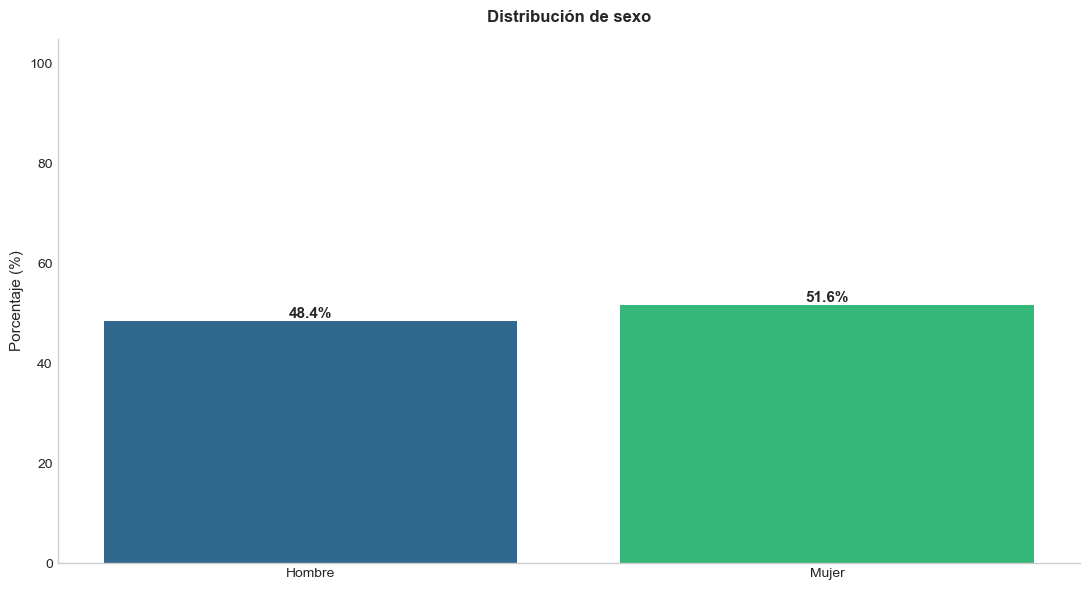

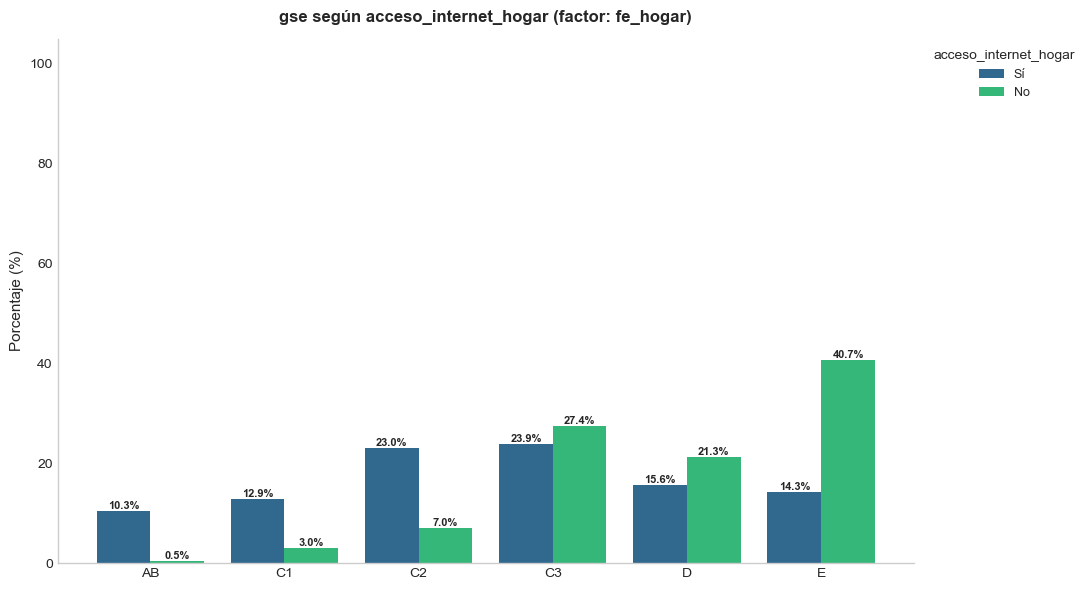

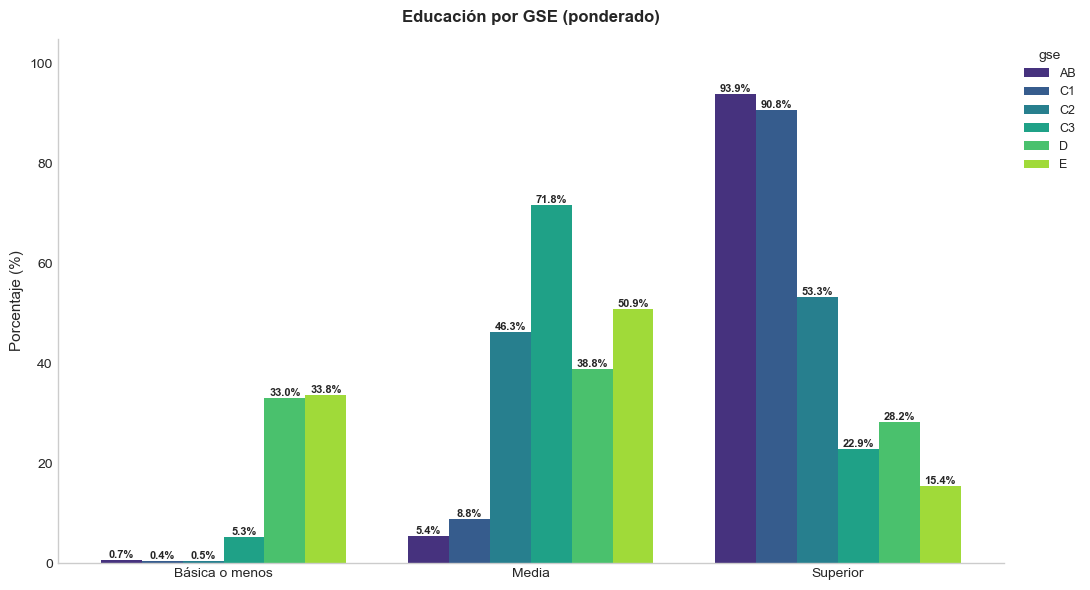

(<Figure size 1100x600 with 1 Axes>,
 <Axes: title={'center': 'Educación por GSE (ponderado)'}, ylabel='Porcentaje (%)'>)

In [163]:
# Ejemplos de uso de generar_grafico

# Distribución simple
generar_grafico('sexo', factor='fe_personas', titulo='Distribución de sexo')

# Cruce simple (barras agrupadas)
generar_grafico('gse', cruce='acceso_internet_hogar', factor='fe_hogar')

# Cruce con barras apiladas
# Personalizar título y paleta
generar_grafico('educ_grupo', cruce='gse', factor='fe_personas', 
                titulo='Educación por GSE (ponderado)', palette='viridis')
